In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import pickle
import sklearn.preprocessing
import corc.utils
import numpy as np
import os
import scipy.stats
import tqdm
import pandas as pd
import corc.our_algorithms

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [8]:
algorithm_name = "Leiden"
dataset_type = "studt"
dim=8

# open dataset
filename = f"../../datasets/densired_{dataset_type}10.pickle"
with open(filename, "rb") as f:
    data = pickle.load(f)

with open("../../cache/densired10/all_results.pickle", "rb") as f:
    all_results = pickle.load(f)
    
# # open clustering objects
# target_filename = (
#         f"../../cache/densired10/{dataset_type}{dim}_{algorithm_name}.pickle"
# )
# with open(target_filename, "rb") as f: 
#     clustering_objects = pickle.load(f)

In [4]:
def extract_densired(data, index, dim):
    X = data[index][dim][:, :-1]
    y = data[index][dim][:, -1]
    X = sklearn.preprocessing.StandardScaler().fit_transform(X)
    return X,y

In [5]:
def extract_avg_ari(X,y,clustering_objects):
    aris = list()
    for model in clustering_objects:
        y_pred = corc.utils.get_prediction(model, X, len(np.unique(y)))
        if y_pred is None: 
            return -np.inf
        ari = sklearn.metrics.adjusted_rand_score(y, y_pred)
        aris.append(ari)
    return np.mean(aris)

In [6]:
def load_algorithms(dataset_type, dim, algorithm_name):
    # open clustering objects
    target_filename = (
            f"../../cache/densired10/{dataset_type}{dim}_{algorithm_name}.pickle"
    )
    if not os.path.exists(target_filename):
        print(f"Warning: file {target_filename} does not exist!")
        return []
    with open(target_filename, "rb") as f: 
        clustering_objects = pickle.load(f)
    return clustering_objects

def extract_aris_for_dataset_and_algo(data, dataset_type, dim, algorithm_name):
    clustering_objects = load_algorithms(dataset_type, dim, algorithm_name)
    if clustering_objects is not None and len(clustering_objects)>0:
        avg_aris = list()
        for i in range(10):
            X, y = extract_densired(data, i,dim)
            if len(clustering_objects) < i or clustering_objects is None:
                print(clustering_objects,i)
            ari = extract_avg_ari(X,y,clustering_objects[i])
            avg_aris.append(ari)
        return avg_aris
    else: 
        return None

In [9]:
all_results

{'studt': {8: {'AgglomerativeClustering': [0.5760090068620672,
    0.7108776026082183,
    0.4720159836960388,
    0.3662209151112937,
    0.6552706917182578,
    0.6906400435080898,
    0.5780627157012728,
    0.805740726855025,
    0.7970851076338363,
    0.8880142218191501],
   'HDBSCAN': [-0.005260657119003877,
    0.05734631749144252,
    0.017684481667139287,
    -0.0031082794230870036,
    0.0013298092874427902,
    0.015026534079851031,
    0.022873837788660208,
    0.05286601129619275,
    0.024837835360386317,
    0.03091284238259151],
   'GaussianMixture': [0.5174286626078739,
    0.4355293450433195,
    0.552623032327855,
    0.34102170380548585,
    0.4107484021377054,
    0.5978589573081198,
    0.5283300019430026,
    0.582554501414797,
    0.6741383735887142,
    0.6829953800948809],
   'Leiden': [0.7140967842119375,
    0.5812514977297135,
    0.5572928939539294,
    0.59746936280279,
    0.891138537228763,
    0.8824365129237868,
    0.7657048846611121,
    0.91111400

In [12]:
for dataset_type in ["studt", "circles"]:
    if dataset_type not in all_results.keys() or all_results[dataset_type] is None:
        all_results[dataset_type] = dict()
    filename = f"../../datasets/densired_{dataset_type}10.pickle"
    with open(filename, "rb") as f:
        data = pickle.load(f)

    for dim in [64, 8,16,32]:
        if dim not in all_results[dataset_type].keys() or all_results[dataset_type][dim] is None:
            all_results[dataset_type][dim] = dict()
        for algorithm_name in tqdm.tqdm(corc.our_algorithms.CORE_SELECTOR, desc=f"{dataset_type}{dim}"):
            algorithm_name = algorithm_name.replace("\n", "")
            if not all_results[dataset_type][dim].get(algorithm_name):
                all_results[dataset_type][dim][algorithm_name] = extract_aris_for_dataset_and_algo(data, dataset_type, dim, algorithm_name)
with open("../../cache/densired10/all_results.pickle", "wb") as f:
    pickle.dump(all_results,f)

studt64:   0%|          | 0/9 [00:00<?, ?it/s]

6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 5 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 4 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 5 clusters i

studt64: 100%|██████████| 9/9 [00:06<00:00,  1.29it/s]


6 clusters is not achievable.
Working with 1 clusters instead.


circles32: 100%|██████████| 9/9 [00:10<00:00,  1.13s/it]


In [13]:

# Create a DataFrame to store the means
core_selector = [algorithm_name.replace("\n", "") for algorithm_name in corc.our_algorithms.CORE_SELECTOR]
means_df = pd.DataFrame(index=core_selector, columns=[f"{dataset_type}_{dim}" for dataset_type in ["circles", "studt"] for dim in [8,16,32,64]])
# means_df = pd.DataFrame(index=corc.our_algorithms.CORE_SELECTOR, columns=[f"{dataset_type}_{dim}" for dataset_type in ["circles", "studt"] for dim in [8,16,32,64]])

# Calculate the means and store them in the DataFrame
for dataset_type in ["circles", "studt"]:
    for dim in [8,16,32,64]:
        for algorithm_name in corc.our_algorithms.CORE_SELECTOR:
            algorithm_name = algorithm_name.replace("\n", "")
            means_df.loc[algorithm_name, f"{dataset_type}_{dim}"] = sum(all_results[dataset_type][dim][algorithm_name]) / len(all_results[dataset_type][dim][algorithm_name]) if all_results[dataset_type][dim][algorithm_name] else None

means_df

,circles_8,circles_16,circles_32,circles_64,studt_8,studt_16,studt_32,studt_64
AgglomerativeClustering,0.70,0.67,0.68,0.69,0.65,0.73,0.67,0.67
HDBSCAN,0.15,0.34,0.26,0.53,0.02,0.02,0.02,0.02
GaussianMixture,0.65,0.67,0.66,0.67,0.53,0.40,0.25,0.16
Leiden,0.75,0.66,0.81,0.78,0.77,0.81,0.85,0.88
GWG-dip,0.87,0.62,0.97,0.84,0.15,0.27,0.12,0.16
UniForCE,0.12,0.19,0.12,0.22,0.16,0.32,0.40,0.51
SMMP,0.57,0.69,0.59,0.67,0.24,0.46,0.61,-inf
GMM-NEB,0.87,0.95,0.90,0.90,0.67,0.56,0.28,0.16
TMM-NEB,0.92,0.98,0.99,0.99,0.86,0.88,0.80,0.68


In [14]:
print(means_df)

                        circles_8 circles_16 circles_32 circles_64 studt_8  \
AgglomerativeClustering      0.70       0.67       0.68       0.69    0.65   
HDBSCAN                      0.15       0.34       0.26       0.53    0.02   
GaussianMixture              0.65       0.67       0.66       0.67    0.53   
Leiden                       0.75       0.66       0.81       0.78    0.77   
GWG-dip                      0.87       0.62       0.97       0.84    0.15   
UniForCE                     0.12       0.19       0.12       0.22    0.16   
SMMP                         0.57       0.69       0.59       0.67    0.24   
GMM-NEB                      0.87       0.95       0.90       0.90    0.67   
TMM-NEB                      0.92       0.98       0.99       0.99    0.86   

                        studt_16 studt_32 studt_64  
AgglomerativeClustering     0.73     0.67     0.67  
HDBSCAN                     0.02     0.02     0.02  
GaussianMixture             0.40     0.25     0.16  
Leiden 

In [16]:
import pandas as pd
import numpy as np

core_selector = [alg.replace("\n", "") for alg in corc.our_algorithms.CORE_SELECTOR]
dataset_types = ["circles", "studt"]
dims = [8, 16, 32, 64]
columns = [f"{dtype}_{dim}" for dtype in dataset_types for dim in dims]

# Calculate means and stds
means = pd.DataFrame(index=core_selector, columns=columns)
stds = pd.DataFrame(index=core_selector, columns=columns)

for dtype in dataset_types:
    for dim in dims:
        for alg in corc.our_algorithms.CORE_SELECTOR:
            name = alg.replace("\n", "")
            values = all_results[dtype][dim][name]
            if values:
                # Convert to numpy array and mask out -np.inf
                values_arr = np.asarray(values)
                finite_values = values_arr[values_arr != -np.inf]
                if finite_values.size > 0:
                    means.loc[name, f"{dtype}_{dim}"] = np.mean(finite_values)
                    stds.loc[name, f"{dtype}_{dim}"] = np.std(finite_values)
                else:
                    means.loc[name, f"{dtype}_{dim}"] = np.nan
                    stds.loc[name, f"{dtype}_{dim}"] = np.nan
            else:
                means.loc[name, f"{dtype}_{dim}"] = np.nan
                stds.loc[name, f"{dtype}_{dim}"] = np.nan

# Create formatted result table
def pretty_entry(mean, std):
    if pd.isna(mean) or pd.isna(std):
        return ""
    return f"{mean:.2f}±{std:.2f}"

table = pd.DataFrame(index=means.index, columns=means.columns)

for row in means.index:
    for col in means.columns:
        table.loc[row, col] = pretty_entry(means.loc[row, col], stds.loc[row, col])

print(table)

                         circles_8 circles_16 circles_32 circles_64  \
AgglomerativeClustering  0.70±0.10  0.67±0.12  0.68±0.16  0.69±0.12   
HDBSCAN                  0.15±0.28  0.34±0.40  0.26±0.36  0.53±0.46   
GaussianMixture          0.65±0.10  0.67±0.13  0.66±0.11  0.67±0.11   
Leiden                   0.75±0.10  0.66±0.13  0.81±0.15  0.78±0.13   
GWG-dip                  0.87±0.13  0.62±0.17  0.97±0.05  0.84±0.10   
UniForCE                 0.12±0.12  0.19±0.20  0.12±0.16  0.22±0.22   
SMMP                     0.57±0.18  0.69±0.12  0.59±0.23  0.67±0.17   
GMM-NEB                  0.87±0.19  0.95±0.08  0.90±0.20  0.90±0.18   
TMM-NEB                  0.92±0.10  0.98±0.05  0.99±0.02  0.99±0.03   

                           studt_8   studt_16   studt_32   studt_64  
AgglomerativeClustering  0.65±0.15  0.73±0.14  0.67±0.18  0.67±0.17  
HDBSCAN                  0.02±0.02  0.02±0.02  0.02±0.02  0.02±0.02  
GaussianMixture          0.53±0.11  0.40±0.06  0.25±0.09  0.16±0.09  
Leiden   

In [30]:
results = all_results["studt"][8]
best_algo="TMM-NEB"
# best_algo="Leiden"
for method in results.keys():
    print(f"{'not' if scipy.stats.ttest_rel(results[best_algo], results[method])[1] > 0.05 else ''} significant {best_algo} vs {method}")


 significant TMM-NEB vs AgglomerativeClustering
 significant TMM-NEB vs HDBSCAN
 significant TMM-NEB vs GaussianMixture
not significant TMM-NEB vs Leiden
 significant TMM-NEB vs GWG-dip
 significant TMM-NEB vs UniForCE
 significant TMM-NEB vs SMMP
 significant TMM-NEB vs GMM-NEB
 significant TMM-NEB vs TMM-NEB


In [139]:
dataset_type

'circles'

In [133]:
dim=8

In [142]:
pd.DataFrame((results["Leiden"], results["TMM-NEB"]))

,0,1,2,3,4,5,6,7,8,9
0,0.71,0.58,0.56,0.60,0.89,0.88,0.77,0.91,0.88,0.92
1,0.88,0.86,0.91,0.88,0.88,0.70,0.85,0.92,0.85,0.92


In [44]:
import corc.tmm_plots

In [ ]:
corc.tmm_plots.plot_tmm_models()

In [65]:
X, y = extract_densired(data, 1,8)
models = load_algorithms("studt", 8, "TMM-NEB")

In [49]:
models[1]

In [51]:
import tsnecuda

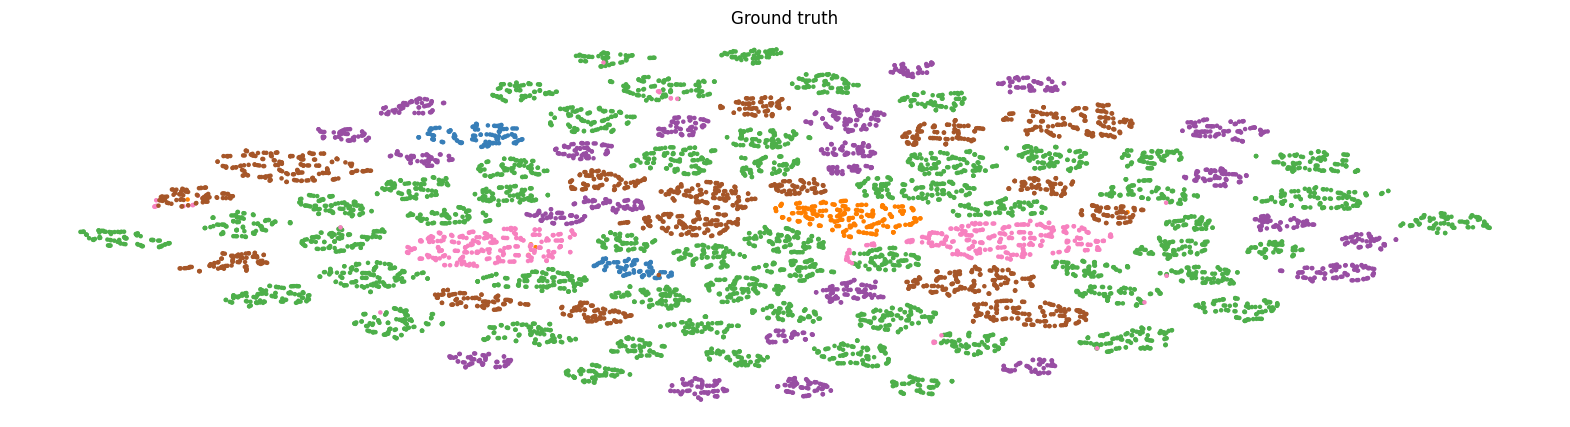

In [126]:
tsne = tsnecuda.TSNE(n_components=2, perplexity=5, learning_rate=1000, n_iter=1000)
X2 = tsne.fit_transform(X)
figure = corc.tmm_plots.plot_tmm_models([], X, y, "studt8", X2)

In [68]:
y = np.array(y, dtype=int)

In [127]:
tsne = sklearn.manifold.TSNE()
X2 = tsne.fit_transform(X)

KeyboardInterrupt: 

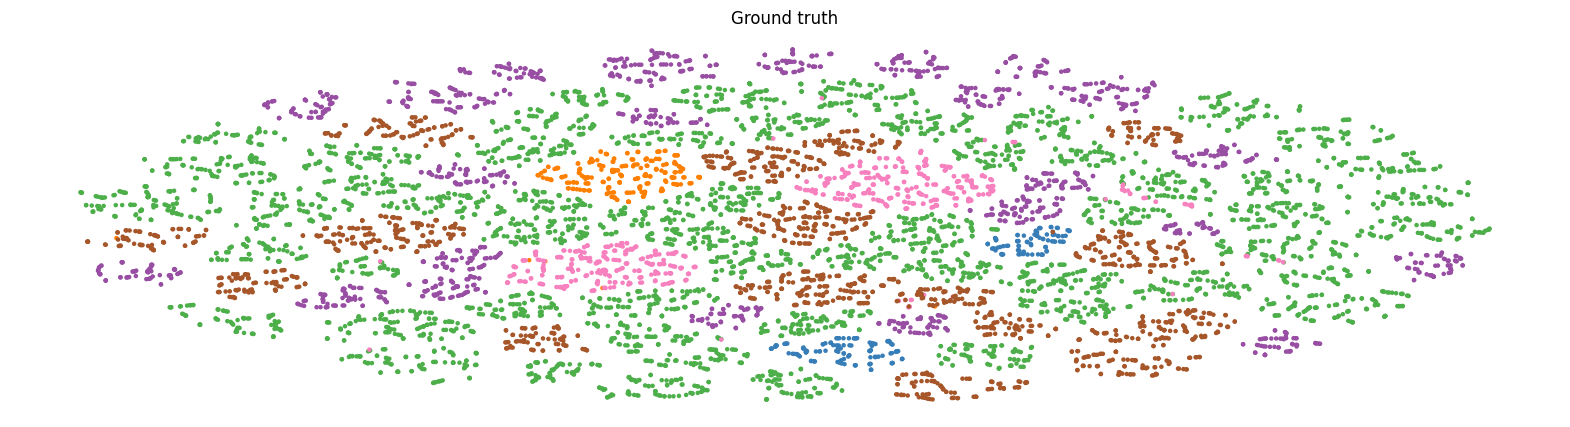

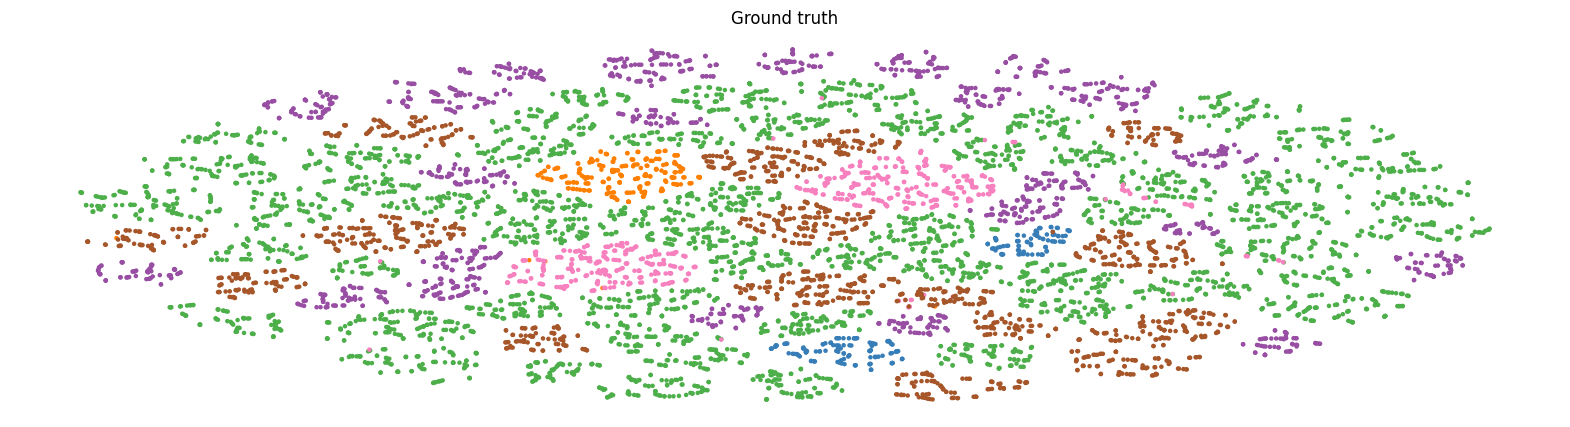

In [120]:
corc.tmm_plots.plot_tmm_models([], X, y, "studt8", X2)

In [76]:
my_model = corc.graph_metrics.neb.NEB(
    data=X, labels=y, tmm_regularization=0.001,min_cluster_size=50
)
my_model.fit(X)

Mixture model fit took 10.78 seconds.
[[669   5]
 [449   3]
 [233   4]
 [224   2]
 [404   4]
 [191   4]
 [342   4]
 [598   4]
 [604   5]
 [669   4]
 [670   6]
 [306   7]
 [638   3]
 [248   3]
 [453   4]
 [244   3]
 [108   4]
 [563   5]
 [334   7]
 [376   3]
 [181   6]
 [395   5]
 [137   5]
 [764   3]
 [200   4]]
After filtering 25 components, we are left with 25 components


t-NEB: 100%|██████████| 2/2 [00:17<00:00,  8.82s/it]


In [78]:
y_pred =my_model.predict_with_target(X,6)

In [79]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2, 3, 4, 5], dtype=int32),
 array([6077, 1355,  224, 1851,  248,  245]))

In [80]:
sklearn.metrics.adjusted_rand_score(y, y_pred)

0.8314725257101676

In [71]:
import cuml

ModuleNotFoundError: No module named 'cuml'